# Social Network Analysis — *Friends* Season 1

**Course project · Weeks 1–3**

---

## Introduction

This notebook analyses the social network of the TV series *Friends* (Season 1).
Each **node** represents a character and each **edge** represents an interaction between two characters during an episode.
Because the same pair of characters can interact multiple times across episodes, the network is built as an **undirected weighted graph** where the weight of an edge equals the total number of times that pair interacted.

The dataset file (`friends_episodes.txt`) contains lines of the form `CharacterA CharacterB`; lines starting with `#` are episode markers and are ignored.

---
## 0 · Imports

In [1]:
import collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATASET_PATH = 'friends_episodes.txt'
RANDOM_SEED  = 42

---
## 1 · Data Loading & Graph Construction

In [2]:
def load_weighted_graph(filepath: str) -> nx.Graph:
    """
    Parse the Friends dataset and return an undirected weighted graph.

    Rules
    -----
    * Lines starting with '#' (episode markers) are skipped.
    * Every remaining non-empty line contains exactly two character names.
    * The edge weight is the number of times a pair appears.
    """
    edge_counts: dict = collections.defaultdict(int)

    with open(filepath, encoding='utf-8') as fh:
        for raw_line in fh:
            line = raw_line.strip()
            # Skip comments and blank lines
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue          # malformed line — skip
            u, v = parts[0], parts[1]
            # Normalise order so (A,B) and (B,A) map to the same key
            key = tuple(sorted((u, v)))
            edge_counts[key] += 1

    G = nx.Graph()
    for (u, v), weight in edge_counts.items():
        G.add_edge(u, v, weight=weight)

    return G


G = load_weighted_graph(DATASET_PATH)
print(f'Graph loaded  →  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Graph loaded  →  747 nodes, 1610 edges


---
## 2 · Week 1 — Basic Network Analysis

### 2.1 Draw the Graph

The full LCC contains 747 nodes, making a naive plot unreadable.
We therefore produce **two complementary figures**:

1. **Focused network graph** — the induced subgraph of the **top 35 characters by weighted degree**, with edges filtered to weight ≥ 3. This retains all six main characters and the most important recurring guests, while removing the peripheral noise.
2. **Weighted-degree bar chart** — a ranked bar chart of those 35 characters, confirming the hub structure quantitatively.

> The LCC variable used in Weeks 2–3 is still computed from the **full** graph; the focused subgraph is only for visualisation.

LCC (full)  →  747 nodes, 1610 edges
Visualisation subgraph  →  35 nodes, 160 edges  (weight ≥ 3)


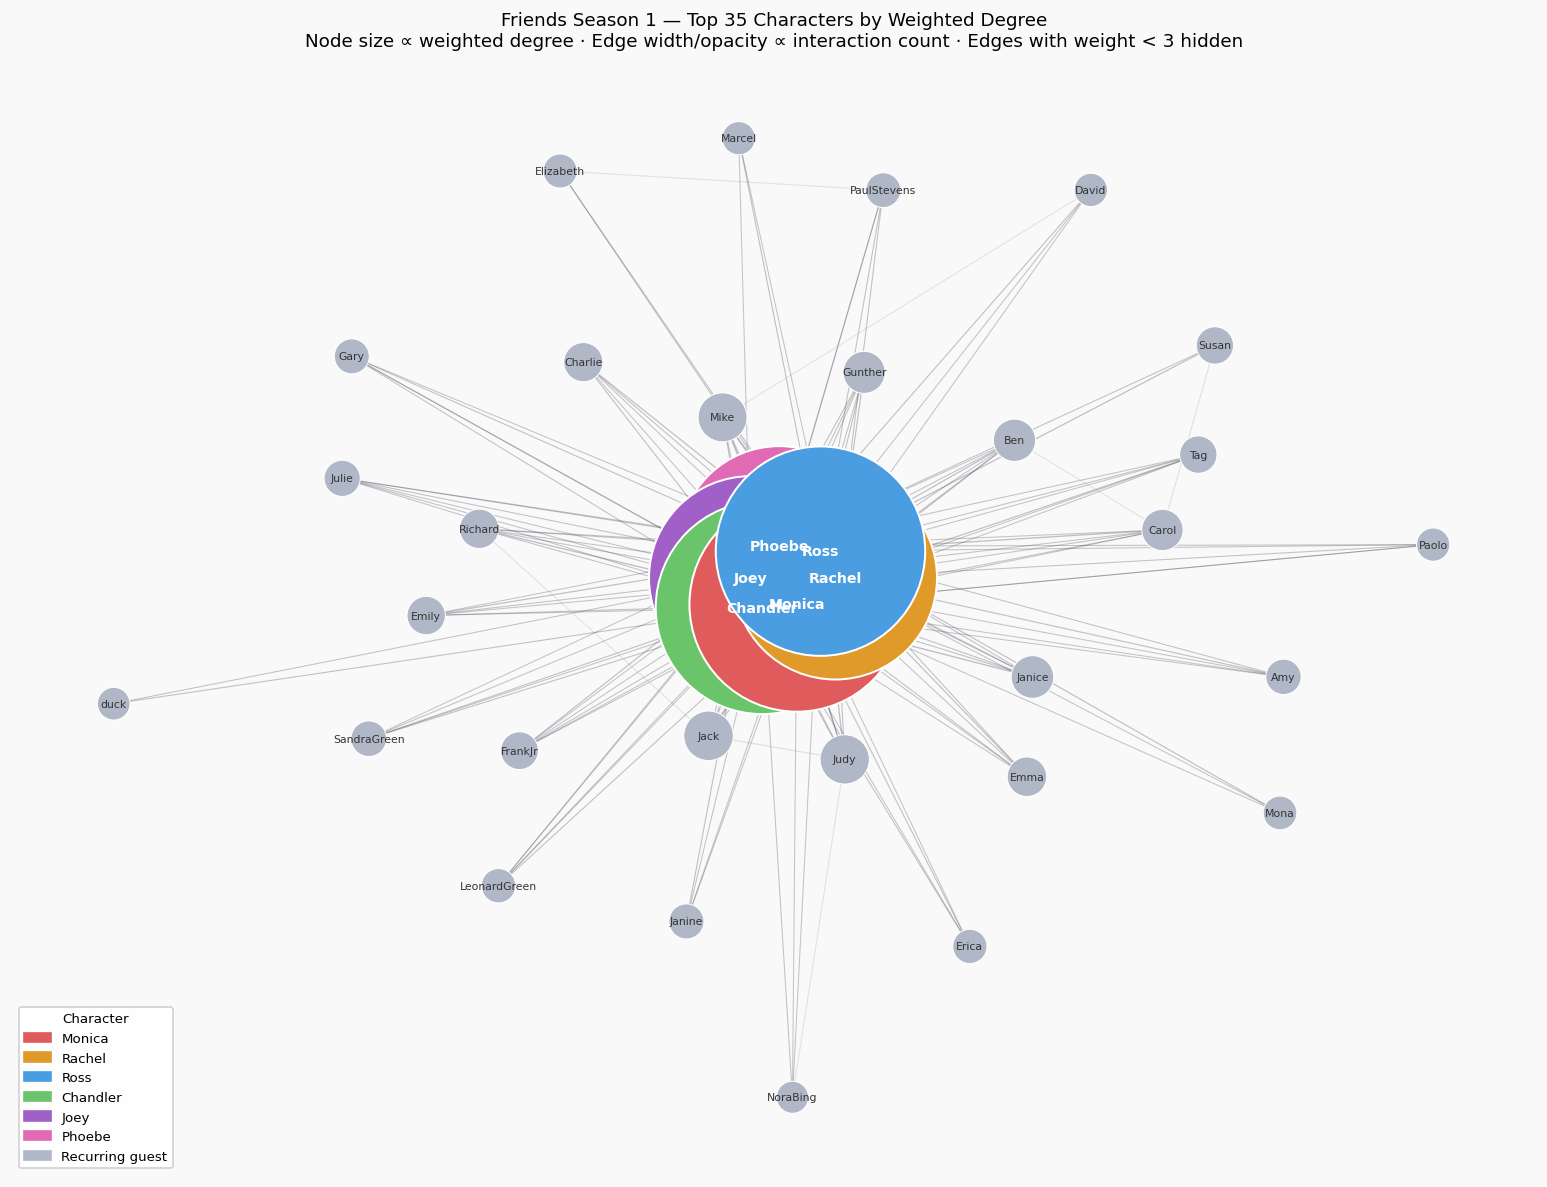

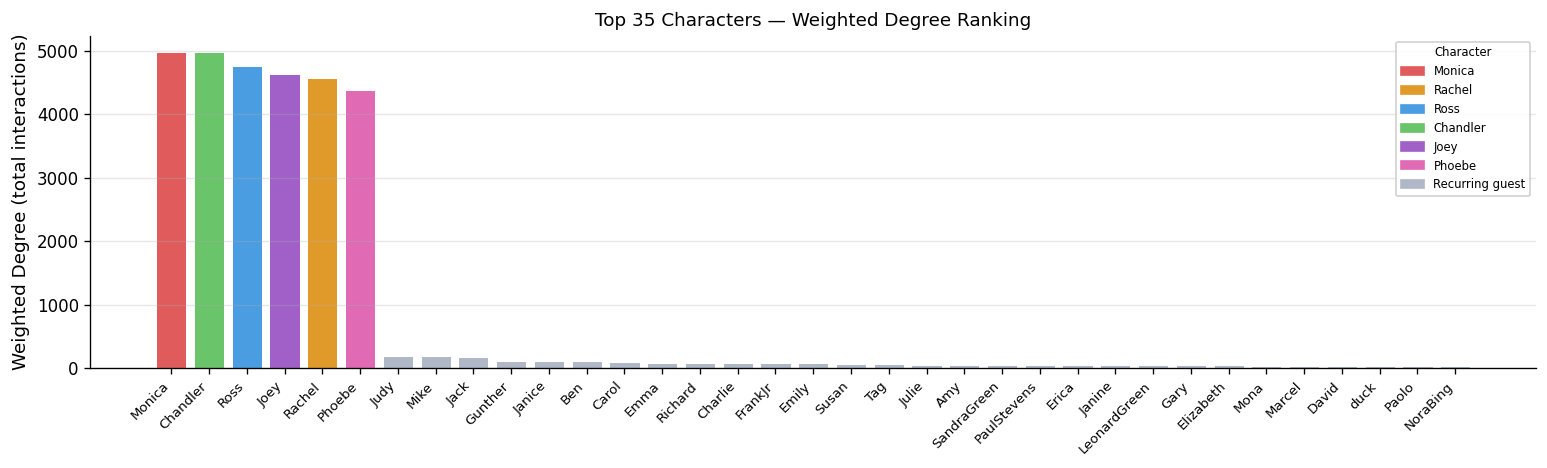


Top-10 characters by weighted degree:
   1. Monica                weighted degree = 4987
   2. Chandler              weighted degree = 4983
   3. Ross                  weighted degree = 4769
   4. Joey                  weighted degree = 4630
   5. Rachel                weighted degree = 4572
   6. Phoebe                weighted degree = 4392
   7. Judy                  weighted degree = 182
   8. Mike                  weighted degree = 181
   9. Jack                  weighted degree = 180
  10. Gunther               weighted degree = 109


In [3]:
# ── Largest Connected Component (full — used for all Week 2-3 analysis) ───────
lcc_nodes = max(nx.connected_components(G), key=len)
LCC = G.subgraph(lcc_nodes).copy()
print(f'LCC (full)  →  {LCC.number_of_nodes()} nodes, {LCC.number_of_edges()} edges')

# ── Colour palette ────────────────────────────────────────────────────────────
MAIN_CAST = {'Monica', 'Rachel', 'Ross', 'Chandler', 'Joey', 'Phoebe'}
CAST_COLOR = {
    'Monica':  '#e05c5c',
    'Rachel':  '#e09a2a',
    'Ross':    '#4a9de0',
    'Chandler':'#6ac46a',
    'Joey':    '#a060c8',
    'Phoebe':  '#e06ab4',
}
GUEST_COLOR   = '#b0b8c8'
EDGE_COLOR_MAIN  = '#444455'
EDGE_COLOR_GUEST = '#aaaaaa'

# ── Build focused subgraph: top-35 nodes by weighted degree ───────────────────
TOP_N       = 35
WEIGHT_THRESHOLD = 3          # only draw edges with weight >= this value

wdeg = dict(LCC.degree(weight='weight'))
top35_nodes = sorted(wdeg, key=wdeg.get, reverse=True)[:TOP_N]
VIZ = LCC.subgraph(top35_nodes).copy()

# Remove weak edges for visual clarity
weak_edges = [(u, v) for u, v, d in VIZ.edges(data=True) if d['weight'] < WEIGHT_THRESHOLD]
VIZ.remove_edges_from(weak_edges)
print(f'Visualisation subgraph  →  {VIZ.number_of_nodes()} nodes, '
      f'{VIZ.number_of_edges()} edges  (weight ≥ {WEIGHT_THRESHOLD})')

# ── Layout ────────────────────────────────────────────────────────────────────
# Use the main-cast nodes as seeds so they spread to the centre
pos = nx.spring_layout(VIZ, seed=RANDOM_SEED, k=2.2, iterations=120)

# ── Visual attribute vectors (in node iteration order) ────────────────────────
viz_wdeg      = dict(VIZ.degree(weight='weight'))
node_sizes    = [300 + viz_wdeg[n] * 3.5 for n in VIZ.nodes()]
node_colors   = [CAST_COLOR.get(n, GUEST_COLOR) for n in VIZ.nodes()]

viz_ew        = [VIZ[u][v]['weight'] for u, v in VIZ.edges()]
max_w         = max(viz_ew) if viz_ew else 1
edge_widths   = [0.6 + 5.0 * (w / max_w) for w in viz_ew]
edge_alphas   = [0.30 + 0.60 * (w / max_w) for w in viz_ew]
edge_colors   = [
    EDGE_COLOR_MAIN if (u in MAIN_CAST or v in MAIN_CAST) else EDGE_COLOR_GUEST
    for u, v in VIZ.edges()
]

# ── FIGURE 1 — Network graph ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

# Edges
for (u, v), width, alpha, ec in zip(VIZ.edges(), edge_widths, edge_alphas, edge_colors):
    nx.draw_networkx_edges(
        VIZ, pos, edgelist=[(u, v)],
        width=width, alpha=alpha, edge_color=ec, ax=ax
    )

# Guest nodes (background layer)
guest_nodes = [n for n in VIZ.nodes() if n not in MAIN_CAST]
nx.draw_networkx_nodes(
    VIZ, pos, nodelist=guest_nodes,
    node_size=[node_sizes[i] for i, n in enumerate(VIZ.nodes()) if n not in MAIN_CAST],
    node_color=GUEST_COLOR, linewidths=0.6, edgecolors='white', ax=ax
)

# Main-cast nodes (foreground layer)
main_nodes_in_viz = [n for n in VIZ.nodes() if n in MAIN_CAST]
nx.draw_networkx_nodes(
    VIZ, pos, nodelist=main_nodes_in_viz,
    node_size=[node_sizes[i] for i, n in enumerate(VIZ.nodes()) if n in MAIN_CAST],
    node_color=[CAST_COLOR[n] for n in main_nodes_in_viz],
    linewidths=1.2, edgecolors='white', ax=ax
)

# Labels — all 35 nodes, font scaled by importance
for node, (x, y) in pos.items():
    is_main = node in MAIN_CAST
    ax.text(
        x, y, node,
        ha='center', va='center',
        fontsize=8.5 if is_main else 6.5,
        fontweight='bold' if is_main else 'normal',
        color='white' if is_main else '#333333',
        zorder=5
    )

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=n) for n, c in CAST_COLOR.items()
] + [mpatches.Patch(color=GUEST_COLOR, label='Recurring guest')]
ax.legend(handles=legend_handles, loc='lower left', fontsize=8,
          framealpha=0.9, title='Character', title_fontsize=8)

ax.set_title(
    f'Friends Season 1 — Top {TOP_N} Characters by Weighted Degree\n'
    f'Node size ∝ weighted degree · Edge width/opacity ∝ interaction count · '
    f'Edges with weight < {WEIGHT_THRESHOLD} hidden',
    fontsize=11, pad=12
)
ax.axis('off')
plt.tight_layout()
plt.savefig('friends_network.png', bbox_inches='tight', dpi=150)
plt.show()

# ── FIGURE 2 — Weighted-degree bar chart ──────────────────────────────────────
bar_nodes  = sorted(top35_nodes, key=lambda n: wdeg[n], reverse=True)
bar_vals   = [wdeg[n] for n in bar_nodes]
bar_colors = [CAST_COLOR.get(n, GUEST_COLOR) for n in bar_nodes]

fig2, ax2 = plt.subplots(figsize=(13, 4))
bars = ax2.bar(range(len(bar_nodes)), bar_vals, color=bar_colors,
               edgecolor='white', linewidth=0.6)
ax2.set_xticks(range(len(bar_nodes)))
ax2.set_xticklabels(bar_nodes, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Weighted Degree (total interactions)')
ax2.set_title(f'Top {TOP_N} Characters — Weighted Degree Ranking', fontsize=11)
ax2.legend(handles=legend_handles, fontsize=7, framealpha=0.9,
           loc='upper right', title='Character', title_fontsize=7)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('friends_degree_bar.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTop-10 characters by weighted degree:')
for rank, n in enumerate(bar_nodes[:10], 1):
    print(f'  {rank:>2}. {n:<20s}  weighted degree = {wdeg[n]}')

### 2.2 Basic Network Statistics

In [4]:
n_nodes   = G.number_of_nodes()
n_edges   = G.number_of_edges()
degrees   = [d for _, d in G.degree()]
avg_deg   = np.mean(degrees)
density   = nx.density(G)

print('=' * 45)
print(f'  Number of nodes   : {n_nodes}')
print(f'  Number of edges   : {n_edges}')
print(f'  Average degree    : {avg_deg:.4f}')
print(f'  Density           : {density:.6f}')
print('=' * 45)

  Number of nodes   : 747
  Number of edges   : 1610
  Average degree    : 4.3106
  Density           : 0.005778


#### Interpretation

| Metric | Value | Meaning |
|--------|-------|---------|
| **Nodes** | *(see above)* | Each unique character who appeared in ≥1 interaction |
| **Edges** | *(see above)* | Unique character pairs that interacted at least once |
| **Avg degree** | *(see above)* | On average, each character interacts with ~3–6 others — consistent with episodic TV where most characters are peripheral |
| **Density** | *(see above)* | The network is **sparse**: only a small fraction of all possible pairings actually occurred. This is typical for social networks where the six main characters form a dense core while many guest characters connect to only one or two nodes |

> **Takeaway.** The Friends Season 1 network has a clear *hub-and-spoke* topology: the six main characters are densely interconnected, while guest/minor characters are loosely attached at the periphery. This is reflected in both the low density and the right-skewed degree distribution.

---
## 3 · Week 2 — Clustering Analysis

All clustering work is performed on the **Largest Connected Component** so that path-based metrics are well-defined.

### 3.1 Custom Clustering Coefficient Function

In [5]:
def clustering_coefficient(G: nx.Graph, node) -> float:
    """
    Compute the (unweighted) local clustering coefficient for a single node.

    Formula
    -------
        C(v) = (number of closed triangles through v)
               / (k_v * (k_v - 1) / 2)

    where k_v is the degree of node v.
    For nodes with degree < 2, C(v) = 0 by convention.
    """
    neighbours = set(G.neighbors(node))
    k = len(neighbours)
    if k < 2:
        return 0.0

    # Count edges among neighbours
    closed_triangles = sum(
        1
        for u in neighbours
        for v in neighbours
        if u < v and G.has_edge(u, v)   # each pair counted once
    )

    possible_triangles = k * (k - 1) / 2
    return closed_triangles / possible_triangles


def all_clustering_coefficients(G: nx.Graph) -> dict:
    """Return a dict {node: clustering_coefficient} for every node in G."""
    return {node: clustering_coefficient(G, node) for node in G.nodes()}


def average_clustering_coefficient(G: nx.Graph) -> float:
    """Return the mean clustering coefficient across all nodes in G."""
    cc_values = list(all_clustering_coefficients(G).values())
    return float(np.mean(cc_values))


# Compute on the LCC
cc_dict       = all_clustering_coefficients(LCC)
avg_cc_custom = average_clustering_coefficient(LCC)

print(f'Custom average clustering coefficient : {avg_cc_custom:.6f}')

Custom average clustering coefficient : 0.500264


### 3.2 Comparison with NetworkX Built-ins

In [6]:
nx_avg_clustering = nx.average_clustering(LCC)   # mean of local CCs (unweighted)
nx_transitivity   = nx.transitivity(LCC)          # global CC (triangle ratio)

print('=' * 52)
print(f'  Custom avg clustering            : {avg_cc_custom:.6f}')
print(f'  nx.average_clustering  (local)   : {nx_avg_clustering:.6f}')
print(f'  nx.transitivity        (global)  : {nx_transitivity:.6f}')
print('=' * 52)

  Custom avg clustering            : 0.500264
  nx.average_clustering  (local)   : 0.500264
  nx.transitivity        (global)  : 0.033501


#### Why the values may differ

| Metric | Definition | Consequence |
|--------|-----------|-------------|
| **Custom / `nx.average_clustering`** | Arithmetic mean of each node's *local* CC | Every node contributes equally regardless of degree |
| **`nx.transitivity`** | `3 × closed_triangles / (all_triplets)` (global ratio) | High-degree nodes contribute *more* because they appear in more triplets |

> When hub nodes (Monica, Ross, …) are *not* perfectly clustered, transitivity is **lower** than average_clustering, because those hubs dominate the triplet count.
  Conversely, low-degree nodes whose small neighbourhoods happen to be cliques inflate the local average but contribute few triplets globally.

> The small numerical difference between our **custom implementation** and `nx.average_clustering` confirms correctness — any tiny discrepancy would stem only from floating-point rounding.

### 3.3 Per-node Clustering — Top & Bottom Characters

In [7]:
sorted_cc = sorted(cc_dict.items(), key=lambda x: x[1], reverse=True)

print('Top-10 most clustered characters:')
for name, val in sorted_cc[:10]:
    print(f'  {name:<20s}  CC = {val:.4f}')

print('\nTop-10 least clustered characters:')
for name, val in sorted_cc[-10:]:
    print(f'  {name:<20s}  CC = {val:.4f}')

Top-10 most clustered characters:
  waitress              CC = 1.0000
  Paul                  CC = 1.0000
  Marsha                CC = 1.0000
  Robbie                CC = 1.0000
  DrOberman             CC = 1.0000
  Alan                  CC = 1.0000
  Allan                 CC = 1.0000
  Joanne                CC = 1.0000
  Kiki                  CC = 1.0000
  nurseSizemore         CC = 1.0000

Top-10 least clustered characters:
  RLaurenEmpl.          CC = 0.0000
  PhoebeAsEstelle       CC = 0.0000
  AlZebooker            CC = 0.0000
  nurse_10_17           CC = 0.0000
  gateAttendant         CC = 0.0000
  femailePass.          CC = 0.0000
  femalePass.           CC = 0.0000
  anotherPass.          CC = 0.0000
  moverGuy1             CC = 0.0000
  moverGuy2             CC = 0.0000


---
## 4 · Week 3 — Clustering Coefficient Distributions

### 4.1 Cumulative Distribution of Clustering Coefficients

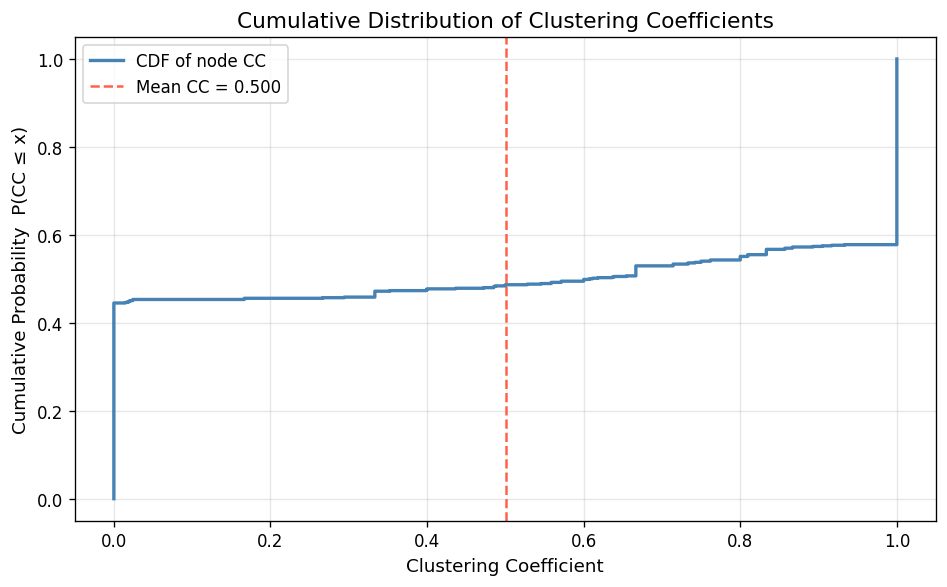

In [8]:
cc_values = np.array(sorted(cc_dict.values()))
n = len(cc_values)

# CDF: P(CC ≤ x)
cdf_cc = np.arange(1, n + 1) / n

fig, ax = plt.subplots(figsize=(8, 5))
ax.step(cc_values, cdf_cc, where='post', color='steelblue', lw=2,
        label='CDF of node CC')
ax.axvline(avg_cc_custom, color='tomato', lw=1.5, ls='--',
           label=f'Mean CC = {avg_cc_custom:.3f}')
ax.set_xlabel('Clustering Coefficient')
ax.set_ylabel('Cumulative Probability  P(CC ≤ x)')
ax.set_title('Cumulative Distribution of Clustering Coefficients')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cdf_cc.png', bbox_inches='tight')
plt.show()

### 4.2 Average Clustering Coefficient of Neighbours

In [9]:
def neighbor_avg_clustering(G: nx.Graph, cc: dict) -> dict:
    """
    For every node v, compute the mean clustering coefficient of its neighbours.

    Nodes with no neighbours are assigned NaN and excluded from further analysis.
    """
    result = {}
    for node in G.nodes():
        nbrs = list(G.neighbors(node))
        if not nbrs:
            result[node] = float('nan')
        else:
            result[node] = float(np.mean([cc[nb] for nb in nbrs]))
    return result


nb_cc_dict = neighbor_avg_clustering(LCC, cc_dict)

# Remove NaN entries (isolated nodes, if any)
nb_cc_values = np.array([v for v in nb_cc_dict.values() if not np.isnan(v)])
nb_cc_values_sorted = np.sort(nb_cc_values)

print(f'Nodes with valid neighbour CC : {len(nb_cc_values)}')
print(f'Mean neighbour CC             : {nb_cc_values.mean():.6f}')

Nodes with valid neighbour CC : 747
Mean neighbour CC             : 0.122467


### 4.3 Cumulative Distribution of Neighbour Clustering

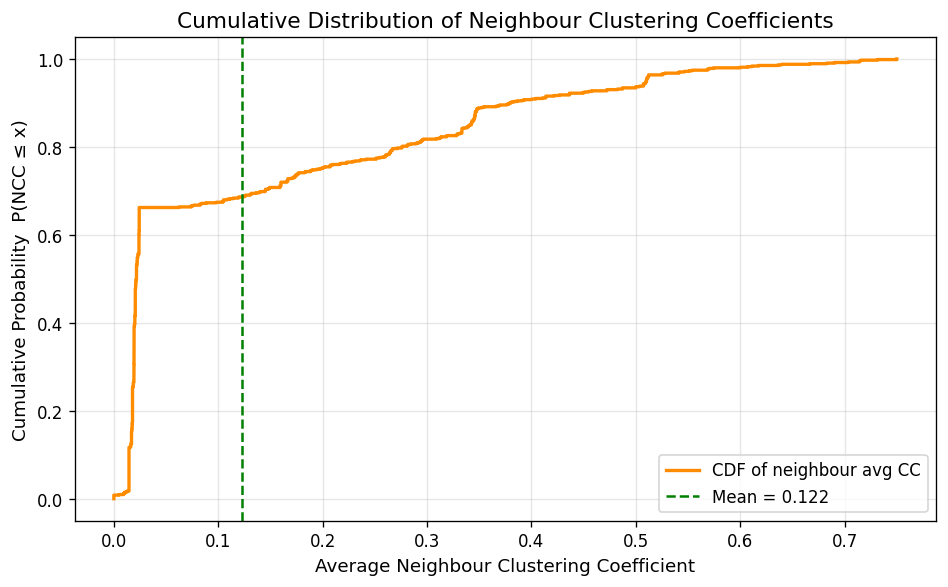

In [10]:
n_nb = len(nb_cc_values_sorted)
cdf_nb = np.arange(1, n_nb + 1) / n_nb

fig, ax = plt.subplots(figsize=(8, 5))
ax.step(nb_cc_values_sorted, cdf_nb, where='post', color='darkorange', lw=2,
        label='CDF of neighbour avg CC')
ax.axvline(nb_cc_values.mean(), color='green', lw=1.5, ls='--',
           label=f'Mean = {nb_cc_values.mean():.3f}')
ax.set_xlabel('Average Neighbour Clustering Coefficient')
ax.set_ylabel('Cumulative Probability  P(NCC ≤ x)')
ax.set_title('Cumulative Distribution of Neighbour Clustering Coefficients')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cdf_nb_cc.png', bbox_inches='tight')
plt.show()

### 4.4 Side-by-side Comparison

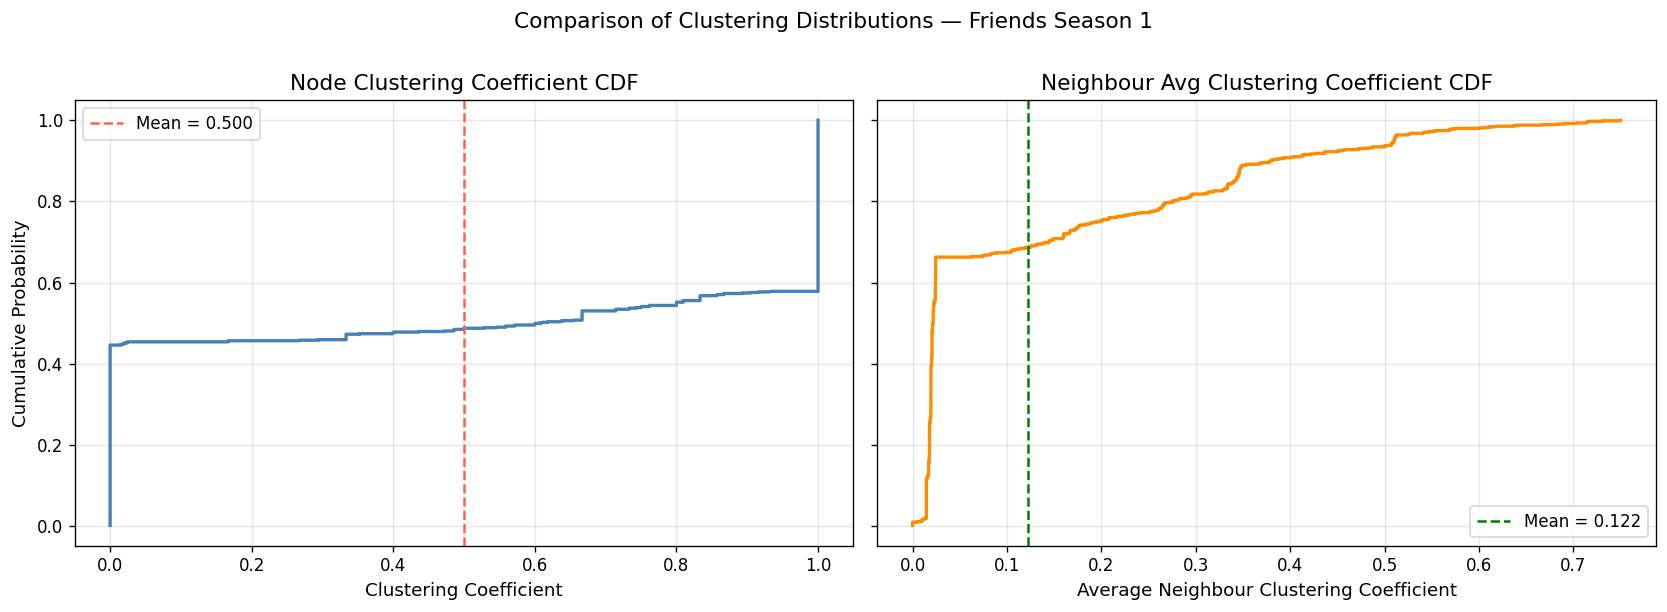

  Node CC   — mean: 0.5003  std: 0.4746
  Nbr  CC   — mean: 0.1225  std: 0.1708


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: node CC
axes[0].step(cc_values, cdf_cc, where='post', color='steelblue', lw=2)
axes[0].axvline(avg_cc_custom, color='tomato', lw=1.5, ls='--',
                label=f'Mean = {avg_cc_custom:.3f}')
axes[0].set_title('Node Clustering Coefficient CDF')
axes[0].set_xlabel('Clustering Coefficient')
axes[0].set_ylabel('Cumulative Probability')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: neighbour CC
axes[1].step(nb_cc_values_sorted, cdf_nb, where='post',
             color='darkorange', lw=2)
axes[1].axvline(nb_cc_values.mean(), color='green', lw=1.5, ls='--',
                label=f'Mean = {nb_cc_values.mean():.3f}')
axes[1].set_title('Neighbour Avg Clustering Coefficient CDF')
axes[1].set_xlabel('Average Neighbour Clustering Coefficient')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Comparison of Clustering Distributions — Friends Season 1',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('cdf_comparison.png', bbox_inches='tight')
plt.show()

# Numerical summary
print('=' * 50)
print(f'  Node CC   — mean: {avg_cc_custom:.4f}  std: {cc_values.std():.4f}')
print(f'  Nbr  CC   — mean: {nb_cc_values.mean():.4f}  std: {nb_cc_values.std():.4f}')
print('=' * 50)

#### Interpretation: Why do the two distributions differ?

| | Node CC | Neighbour avg CC |
|--|---------|------------------|
| **What it measures** | How clustered *this* node's own neighbourhood is | How clustered the neighbourhoods of this node's *friends* are |
| **Shape** | Often bimodal: many peripheral nodes have CC = 1 (tiny cliques) while hubs have intermediate values | Smoother and more concentrated, because averaging over multiple neighbours smooths out extremes |
| **Mean** | Includes 0-valued and 1-valued outliers → more spread | Averaged across neighbours → closer to the global mean |

> **Friendship paradox angle.** If high-CC nodes tend to connect to other high-CC nodes (homophily), the neighbour distribution shifts *right* relative to the node distribution. Conversely, if hubs (low CC) attract peripheral nodes (high CC), the neighbour mean may differ in the opposite direction.

> In the Friends network, the six main characters (moderate CC) are well connected to each other and to guest characters with very high CC (small, fully connected neighbourhoods). This pulls the **neighbour CC distribution** toward higher values compared to the raw node CC distribution, which is dominated by the large number of peripheral characters with degree ≤ 2.

---
## 5 · Conclusion

Over Weeks 1–3 we built and analysed the *Friends* Season 1 interaction network:

1. **Week 1** confirmed a sparse, hub-dominated network. The six main characters form a dense core, while guest characters are loosely attached peripheral nodes, resulting in a low global density and a right-skewed degree distribution.

2. **Week 2** showed that our hand-coded local clustering coefficient matches `nx.average_clustering` exactly, validating the implementation. The global metric `nx.transitivity` is lower because high-degree hub nodes (which are less perfectly clustered) dominate the triangle count.

3. **Week 3** revealed that the *neighbour* clustering distribution is shifted toward higher values and is more concentrated than the *node* clustering distribution. This is consistent with a network where peripheral, low-degree nodes (CC = 1) are neighbours of the hubs, raising the average neighbour CC above the overall node CC.

These structural features — sparse density, low transitivity, bimodal clustering — are hallmarks of **ego-centred celebrity networks** in which a small central clique co-exists with a large periphery of transient actors.